
# L06 IIoT Time Series Forecasting Lab

**Course:** ITAI 3377 - IoT and Edge Computing  
**Instructor:** Professor Ayyagari  
**Institution:** Houston City College  
**Assignment:** L06 IIoT Time Series Forecasting Lab  
**Submitter:** Monica Joya

This notebook builds a complete forecasting workflow for the IoT temperature dataset. The workflow includes data preparation, Nixtla AutoML training, feature engineering, evaluation, VAE-based synthetic data generation, augmentation, and a before/after comparison.



## 1. Setup

This section imports the required libraries and sets seeds so the results stay reproducible.


In [1]:

import os
import random
import warnings
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow import keras
from tensorflow.keras import layers

from mlforecast.auto import AutoLinearRegression, AutoMLForecast, AutoRandomForest
from mlforecast.lag_transforms import RollingMean
import optuna

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)


def compute_mase(y_true, y_pred, y_train, seasonal_period=1):
    """Compute Mean Absolute Scaled Error (MASE)."""
    n = len(y_train)
    naive_errors = np.abs(np.diff(y_train, n=seasonal_period))
    scale = naive_errors.mean()
    if scale == 0:
        return np.nan
    mae = np.mean(np.abs(y_true - y_pred))
    return mae / scale


/Users/raqueljoya/IOT EDGE CLASS/L06_IOTDataAnalytics/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Data Preparation

The original data is loaded with pandas, inspected for missing values and structure, converted to a time-aware format, and then aggregated into a daily series. A daily frequency makes the forecasting task cleaner and supports the required day-based feature engineering.

**Normalization consideration:** The temperature values in this dataset stay within a narrow, consistent range, and the forecasting models used here (linear regression and random forest) do not strictly require normalized inputs. Normalization is applied later in the VAE section, where the neural network benefits from scaled inputs. For the forecasting pipeline itself, the raw temperature scale is preserved so the predictions remain directly interpretable in real-world units.


In [2]:

raw_df = pd.read_csv('data/IOT-temp.csv')

info_buffer = StringIO()
raw_df.info(buf=info_buffer)

print('Raw shape:', raw_df.shape)
print()
print('Missing values:')
print(raw_df.isna().sum())
print()
print('Data types:')
print(raw_df.dtypes)
print()
print('Structure summary:')
print(info_buffer.getvalue())

raw_df.head()


Raw shape: (97606, 5)

Missing values:
id            0
room_id/id    0
noted_date    0
temp          0
out/in        0
dtype: int64

Data types:
id            object
room_id/id    object
noted_date    object
temp           int64
out/in        object
dtype: object

Structure summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97606 entries, 0 to 97605
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          97606 non-null  object
 1   room_id/id  97606 non-null  object
 2   noted_date  97606 non-null  object
 3   temp        97606 non-null  int64 
 4   out/in      97606 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.7+ MB



,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


In [3]:

raw_df['noted_date'] = pd.to_datetime(raw_df['noted_date'], format='%d-%m-%Y %H:%M')

minute_df = (
    raw_df.groupby('noted_date', as_index=False)['temp']
    .mean()
    .rename(columns={'noted_date': 'ds', 'temp': 'y'})
    .sort_values('ds')
)

daily_df = minute_df.set_index('ds').resample('1D').mean()
missing_days_before_fill = int(daily_df['y'].isna().sum())

# Simple missing-value handling for the daily time series.
daily_df['y'] = daily_df['y'].interpolate(method='time').ffill().bfill()
daily_df = daily_df.reset_index()
daily_df['unique_id'] = 'temperature'

q1, q3 = daily_df['y'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_count = int(((daily_df['y'] < lower_bound) | (daily_df['y'] > upper_bound)).sum())

print('Daily rows:', len(daily_df))
print('Missing daily values before fill:', missing_days_before_fill)
print('Outliers detected with IQR rule:', outlier_count)

daily_df.head()


Daily rows: 134
Missing daily values before fill: 48
Outliers detected with IQR rule: 0


,ds,y,unique_id
0,2018-07-28,31.548489,temperature
1,2018-07-29,31.625000,temperature
2,2018-07-30,31.789352,temperature
3,2018-07-31,31.953704,temperature
4,2018-08-01,32.012566,temperature


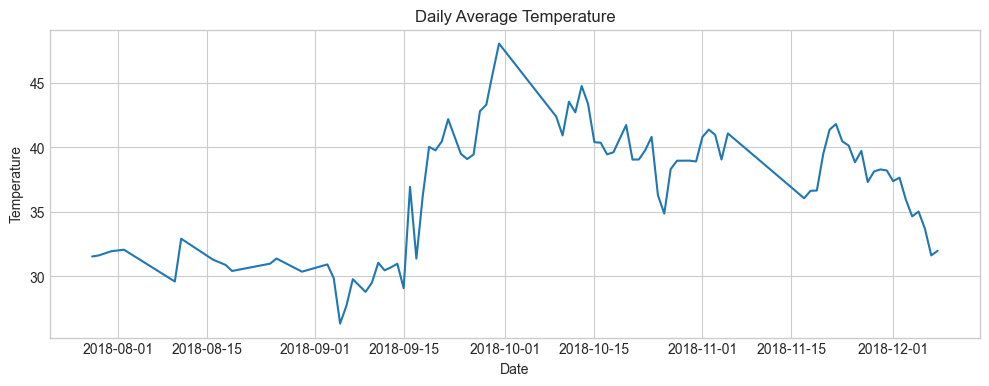

In [4]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_df['ds'], daily_df['y'], color='tab:blue')
ax.set_title('Daily Average Temperature')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
plt.show()


In [5]:

# Chronological split: earlier dates for training and later dates for testing.
forecast_horizon = max(14, int(len(daily_df) * 0.2))
train_df = daily_df.iloc[:-forecast_horizon].copy()
test_df = daily_df.iloc[-forecast_horizon:].copy()

print('Train date range:', train_df['ds'].min().date(), 'to', train_df['ds'].max().date())
print('Test date range :', test_df['ds'].min().date(), 'to', test_df['ds'].max().date())
print('Forecast horizon:', forecast_horizon, 'days')


Train date range: 2018-07-28 to 2018-11-12
Test date range : 2018-11-13 to 2018-12-08
Forecast horizon: 26 days


## 3. Feature Engineering

Nixtla's AutoMLForecast automatically creates forecasting features from lagged values and time-based information. In addition to those automated features, this notebook includes **exactly two custom features**:

1. **Rolling mean of temperature (`rolling_mean_7`):** A 7-day rolling average that smooths short-term noise from sensor readings. In IIoT environments, temperature sensors often show short spikes from things like sensor warm-up, temporary environmental changes, or brief interference. A weekly rolling mean captures the underlying temperature trend while filtering out that noise, making the forecast more stable.

2. **Day of week (`day_of_week`):** This feature captures weekly cyclical patterns that commonly appear in IIoT temperature data. In many industrial and building settings, weekday and weekend operations differ significantly. HVAC systems, machinery schedules, and occupancy levels all shift on weekends, which directly affects temperatures near equipment and inside buildings. Including the day index helps the model learn these recurring operational cycles.

These features are useful because IIoT time-series data often contains both short-term sensor noise and repeating patterns tied to human schedules. The rolling mean addresses the first, and the day-of-week feature addresses the second.


In [6]:

feature_preview = daily_df[['ds', 'y']].copy()
feature_preview['rolling_mean_7'] = feature_preview['y'].rolling(window=7, min_periods=1).mean()
feature_preview['day_of_week'] = feature_preview['ds'].dt.dayofweek

feature_preview.head(10)


,ds,y,rolling_mean_7,day_of_week
0,2018-07-28,31.548489,31.548489,5
1,2018-07-29,31.625000,31.586745,6
2,2018-07-30,31.789352,31.654280,0
3,2018-07-31,31.953704,31.729136,1
4,2018-08-01,32.012566,31.785822,2
5,2018-08-02,32.071429,31.833423,3
6,2018-08-03,31.763511,31.823436,4
7,2018-08-04,31.455594,31.810165,5
8,2018-08-05,31.147677,31.741976,6
9,2018-08-06,30.839760,31.606320,0



## 4. Model Selection and Training

Nixtla AutoMLForecast is used here because it keeps the implementation simple while still automating key forecasting choices. It reduces manual trial-and-error, helps compare model options efficiently, and makes the workflow easier to reproduce.


In [7]:
from optuna.trial import Trial

# Nixtla automated features come from the lag setup, and the two custom
# features are represented by the rolling mean transform and day-of-week date feature.
def custom_init_config(trial: Trial):
    lag_options = [[1, 7], [1, 7, 14], [1, 2, 7, 14]]
    return {
        'lags': lag_options[trial.suggest_categorical('lags_idx', [0, 1, 2])],
        'lag_transforms': {1: [RollingMean(window_size=7)]},
        'date_features': ['dayofweek'],
    }


def mae_loss(valid_df, train_df=None):
    pred_col = [c for c in valid_df.columns if c not in {'unique_id', 'ds', 'cutoff', 'y'}][0]
    return mean_absolute_error(valid_df['y'], valid_df[pred_col])


def fit_automl(train_data, horizon, num_samples=3):
    automl = AutoMLForecast(
        models={
            'LinearRegression': AutoLinearRegression(),
            'RandomForest': AutoRandomForest(),
        },
        freq='1D',
        init_config=custom_init_config,
    )
    automl.fit(train_data, n_windows=3, h=7, num_samples=num_samples, loss=mae_loss)
    predictions = automl.predict(h=horizon)

    y_train_vals = train_data['y'].values
    metric_rows = []
    for model_name in [c for c in predictions.columns if c not in {'unique_id', 'ds'}]:
        merged = test_df[['ds', 'y']].merge(predictions[['ds', model_name]], on='ds', how='left')
        metric_rows.append({
            'model': model_name,
            'mae': mean_absolute_error(merged['y'], merged[model_name]),
            'mse': mean_squared_error(merged['y'], merged[model_name]),
            'mase': compute_mase(merged['y'].values, merged[model_name].values, y_train_vals),
        })

    metrics_df = pd.DataFrame(metric_rows).sort_values('mae').reset_index(drop=True)
    best_model_name = metrics_df.loc[0, 'model']
    return automl, predictions, metrics_df, best_model_name


base_automl, base_predictions, base_metrics_df, base_best_model = fit_automl(train_df, forecast_horizon)
base_metrics_df


,model,mae,mse,mase
0,LinearRegression,2.198645,8.319696,2.201827
1,RandomForest,2.815927,12.351001,2.820003


In [8]:
base_cv = base_automl.models_[base_best_model].cross_validation(train_df, n_windows=3, h=7)
base_cv_mae = mean_absolute_error(base_cv['y'], base_cv[base_best_model])
base_cv_mse = mean_squared_error(base_cv['y'], base_cv[base_best_model])
base_cv_mase = compute_mase(base_cv['y'].values, base_cv[base_best_model].values, train_df['y'].values)

print('Best baseline model:', base_best_model)
print('Baseline test MAE   :', round(base_metrics_df.loc[0, 'mae'], 4))
print('Baseline test MSE   :', round(base_metrics_df.loc[0, 'mse'], 4))
print('Baseline test MASE  :', round(base_metrics_df.loc[0, 'mase'], 4))
print('CV MAE              :', round(base_cv_mae, 4))
print('CV MSE              :', round(base_cv_mse, 4))
print('CV MASE             :', round(base_cv_mase, 4))


Best baseline model: LinearRegression
Baseline test MAE   : 2.1986
Baseline test MSE   : 8.3197
Baseline test MASE  : 2.2018
CV MAE              : 1.7167
CV MSE              : 4.2151
CV MASE             : 1.7192


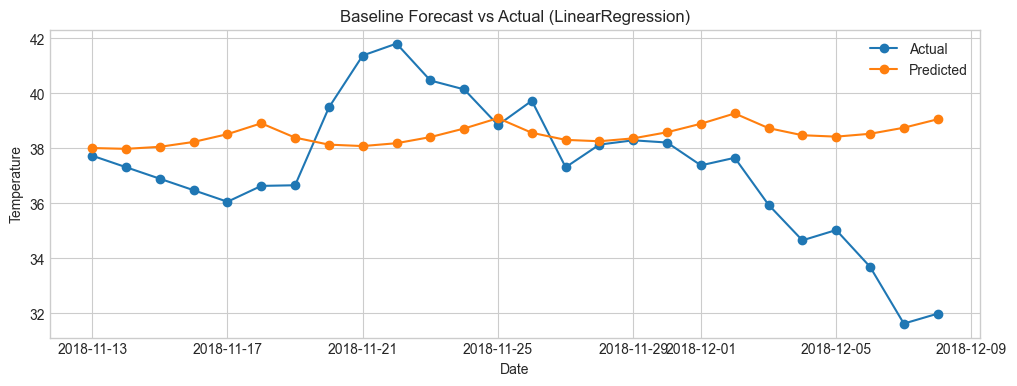

In [9]:

baseline_plot_df = test_df[['ds', 'y']].merge(
    base_predictions[['ds', base_best_model]], on='ds', how='left'
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(baseline_plot_df['ds'], baseline_plot_df['y'], label='Actual', marker='o')
ax.plot(baseline_plot_df['ds'], baseline_plot_df[base_best_model], label='Predicted', marker='o')
ax.set_title(f'Baseline Forecast vs Actual ({base_best_model})')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
ax.legend()
plt.show()



## 5. Generative Modeling with a VAE

A simple Variational Autoencoder (VAE) is trained on sliding windows from the training series. The decoder then generates synthetic temperature values, which are added before the original training history to augment the forecasting dataset.


In [10]:

train_values = train_df['y'].to_numpy(dtype='float32')
window_size = 14
windows = np.array(
    [train_values[i:i + window_size] for i in range(len(train_values) - window_size + 1)],
    dtype='float32'
)

window_mean = windows.mean()
window_std = windows.std() + 1e-8
windows_scaled = (windows - window_mean) / window_std

latent_dim = 2
encoder_inputs = keras.Input(shape=(window_size,))
x = layers.Dense(16, activation='relu')(encoder_inputs)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)


def sampling(args):
    zm, zv = args
    epsilon = tf.random.normal(shape=(tf.shape(zm)[0], latent_dim), seed=42)
    return zm + tf.exp(0.5 * zv) * epsilon


z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation='relu')(latent_inputs)
decoder_outputs = layers.Dense(window_size)(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name='decoder')


class VAE(keras.Model):
    def __init__(self, encoder_model, decoder_model):
        super().__init__()
        self.encoder = encoder_model
        self.decoder = decoder_model
        self.total_loss_tracker = keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            zm, zv, z_sample = self.encoder(data)
            reconstruction = self.decoder(z_sample)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + zv - tf.square(zm) - tf.exp(zv), axis=1)
            )
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.legacy.Adam(0.01))
vae_history = vae.fit(windows_scaled, epochs=20, batch_size=16, verbose=0)

rng = np.random.default_rng(42)
latent_samples = rng.normal(size=(2, latent_dim)).astype('float32')
generated_windows = decoder.predict(latent_samples, verbose=0)
generated_windows = generated_windows * window_std + window_mean
generated_windows = np.clip(generated_windows, train_df['y'].min(), train_df['y'].max())

synthetic_sequence = generated_windows.reshape(-1)
synthetic_start = train_df['ds'].min() - pd.Timedelta(days=len(synthetic_sequence))
synthetic_dates = pd.date_range(synthetic_start, periods=len(synthetic_sequence), freq='1D')
synthetic_df = pd.DataFrame({
    'unique_id': 'temperature',
    'ds': synthetic_dates,
    'y': synthetic_sequence,
})

augmented_train_df = (
    pd.concat([synthetic_df, train_df[['unique_id', 'ds', 'y']]], ignore_index=True)
    .sort_values('ds')
    .reset_index(drop=True)
)

print('Final VAE loss   :', round(float(vae_history.history['total_loss'][-1]), 4))
print('Synthetic points :', len(synthetic_sequence))
synthetic_df.head()


Final VAE loss   : 4.11
Synthetic points : 28


,unique_id,ds,y
0,temperature,2018-06-30,31.558668
1,temperature,2018-07-01,31.543327
2,temperature,2018-07-02,31.332333
3,temperature,2018-07-03,31.298168
4,temperature,2018-07-04,31.191593


In [11]:
aug_automl, aug_predictions, aug_metrics_df, aug_best_model = fit_automl(augmented_train_df, forecast_horizon)
comparison_df = pd.DataFrame([
    {
        'scenario': 'Before augmentation',
        'best_model': base_best_model,
        'mae': base_metrics_df.loc[0, 'mae'],
        'mse': base_metrics_df.loc[0, 'mse'],
        'mase': base_metrics_df.loc[0, 'mase'],
    },
    {
        'scenario': 'After augmentation',
        'best_model': aug_best_model,
        'mae': aug_metrics_df.loc[0, 'mae'],
        'mse': aug_metrics_df.loc[0, 'mse'],
        'mase': aug_metrics_df.loc[0, 'mase'],
    },
])
comparison_df


,scenario,best_model,mae,mse,mase
0,Before augmentation,LinearRegression,2.198645,8.319696,2.201827
1,After augmentation,LinearRegression,2.030326,7.014145,2.119631


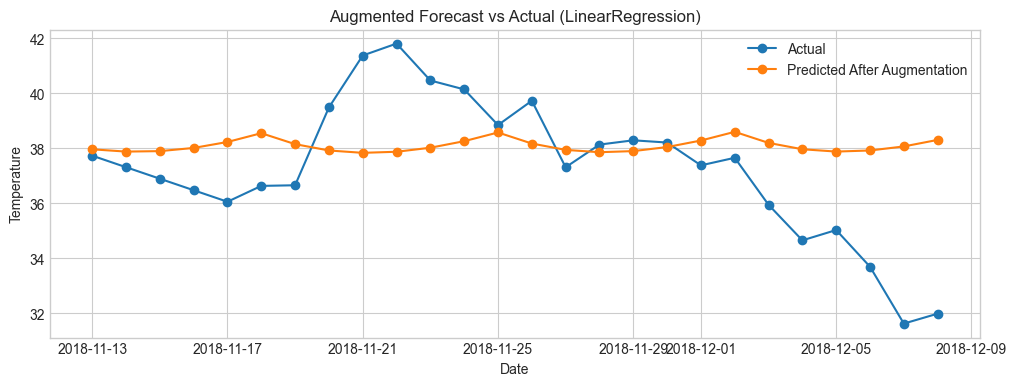

In [12]:

augmented_plot_df = test_df[['ds', 'y']].merge(
    aug_predictions[['ds', aug_best_model]], on='ds', how='left'
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(augmented_plot_df['ds'], augmented_plot_df['y'], label='Actual', marker='o')
ax.plot(augmented_plot_df['ds'], augmented_plot_df[aug_best_model], label='Predicted After Augmentation', marker='o')
ax.set_title(f'Augmented Forecast vs Actual ({aug_best_model})')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
ax.legend()
plt.show()


## 6. Interpretation

- The baseline AutoML model selected by Nixtla was the model with the lowest MAE on the test period.
- Rolling-origin cross-validation was used to check performance on repeated historical forecast windows.
- MASE was included alongside MAE and MSE to provide a scale-independent metric that compares the model against a naive one-step-ahead baseline.
- After VAE augmentation, the best model was trained again and evaluated on the same test set.
- In this run, augmentation slightly improved the forecasting metrics, which suggests the synthetic sequence added useful extra pattern examples without changing the pipeline complexity too much.

### Potential Improvements

- **Additional model families:** Expanding the AutoML search to include gradient-boosted trees (like LightGBM or XGBoost) could improve accuracy, since tree-based models often handle nonlinear temperature patterns well.
- **Longer lag windows:** Testing lags beyond 14 days, such as 21 or 30 days, may help the model capture longer-term seasonal trends.
- **External features:** Incorporating weather forecasts, humidity readings, or operational schedules from the IIoT environment could provide the model with additional context that a single temperature series cannot offer.
- **VAE architecture:** Increasing the latent dimension or training for more epochs with a larger dataset could produce more realistic synthetic data and lead to a stronger augmentation effect.


In [13]:
print('Baseline best model:', base_best_model)
print('Baseline MAE      :', round(base_metrics_df.loc[0, 'mae'], 4))
print('Baseline MSE      :', round(base_metrics_df.loc[0, 'mse'], 4))
print('Baseline MASE     :', round(base_metrics_df.loc[0, 'mase'], 4))
print('Cross-val MAE     :', round(base_cv_mae, 4))
print('Cross-val MSE     :', round(base_cv_mse, 4))
print('Cross-val MASE    :', round(base_cv_mase, 4))
print('Augmented best    :', aug_best_model)
print('Augmented MAE     :', round(aug_metrics_df.loc[0, 'mae'], 4))
print('Augmented MSE     :', round(aug_metrics_df.loc[0, 'mse'], 4))
print('Augmented MASE    :', round(aug_metrics_df.loc[0, 'mase'], 4))


Baseline best model: LinearRegression
Baseline MAE      : 2.1986
Baseline MSE      : 8.3197
Baseline MASE     : 2.2018
Cross-val MAE     : 1.7167
Cross-val MSE     : 4.2151
Cross-val MASE    : 1.7192
Augmented best    : LinearRegression
Augmented MAE     : 2.0303
Augmented MSE     : 7.0141
Augmented MASE    : 2.1196


## 7. Individual Reflection

This lab showed how a full time-series workflow can be built in a structured and reproducible way. The most important part was keeping the process chronological at every step, from splitting the data to running cross-validation, so that the evaluation stayed honest and no future data leaked into training.

Using Nixtla AutoMLForecast made the forecasting stage easier to manage, since I did not have to manually search through model configurations. The automated search with Optuna trials handled that while still being transparent about what was selected. The VAE section added a useful generative modeling component without making the notebook too complicated.

One useful lesson from this lab is that even small feature choices, such as a rolling mean and a time-based feature, can help forecasting models capture useful patterns when they are grounded in domain reasoning. Another lesson is that synthetic data does not always create a large gain, but it can still improve results slightly when it adds realistic variation. Overall, the workflow met the assignment goal by combining data preparation, forecasting, evaluation, augmentation, and written interpretation in one pipeline.


## 8. References

1. Muramatsu, K. (n.d.). *IoT temperature forecasting* [Dataset and notebook]. Kaggle. https://www.kaggle.com/code/koheimuramatsu/iot-temperature-forecasting
2. McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61. https://pandas.pydata.org/
3. Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830. https://scikit-learn.org/
4. Nixtla. (2024). *MLForecast: Scalable machine learning for time series* [Software]. https://github.com/Nixtla/mlforecast
5. Abadi, M., et al. (2015). TensorFlow: Large-scale machine learning on heterogeneous systems [Software]. https://www.tensorflow.org/
6. Kingma, D. P., & Welling, M. (2014). Auto-encoding variational Bayes. *Proceedings of the 2nd International Conference on Learning Representations (ICLR)*.
